In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_theme()

# 1

In [2]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd() / "mutual_fund_project"

nav_path = project_root / "data" / "raw" / "02_nav_history.csv"

print(nav_path)

nav_df = pd.read_csv(nav_path)

nav_df.head()


C:\Users\Shruti Singhania\mutual_fund_project\data\raw\02_nav_history.csv


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [3]:
nav_df['date'] = pd.to_datetime(nav_df['date'],format='mixed')

In [4]:
print(nav_df.isnull().sum())

amfi_code    0
date         0
nav          0
dtype: int64


In [5]:
daily_nav = (nav_df.groupby('date')['nav'].mean().reset_index())
daily_nav.head()

,date,nav
0,2022-01-03,207.213793
1,2022-01-04,206.890585
2,2022-01-05,207.226548
3,2022-01-06,207.190405
4,2022-01-07,207.081100


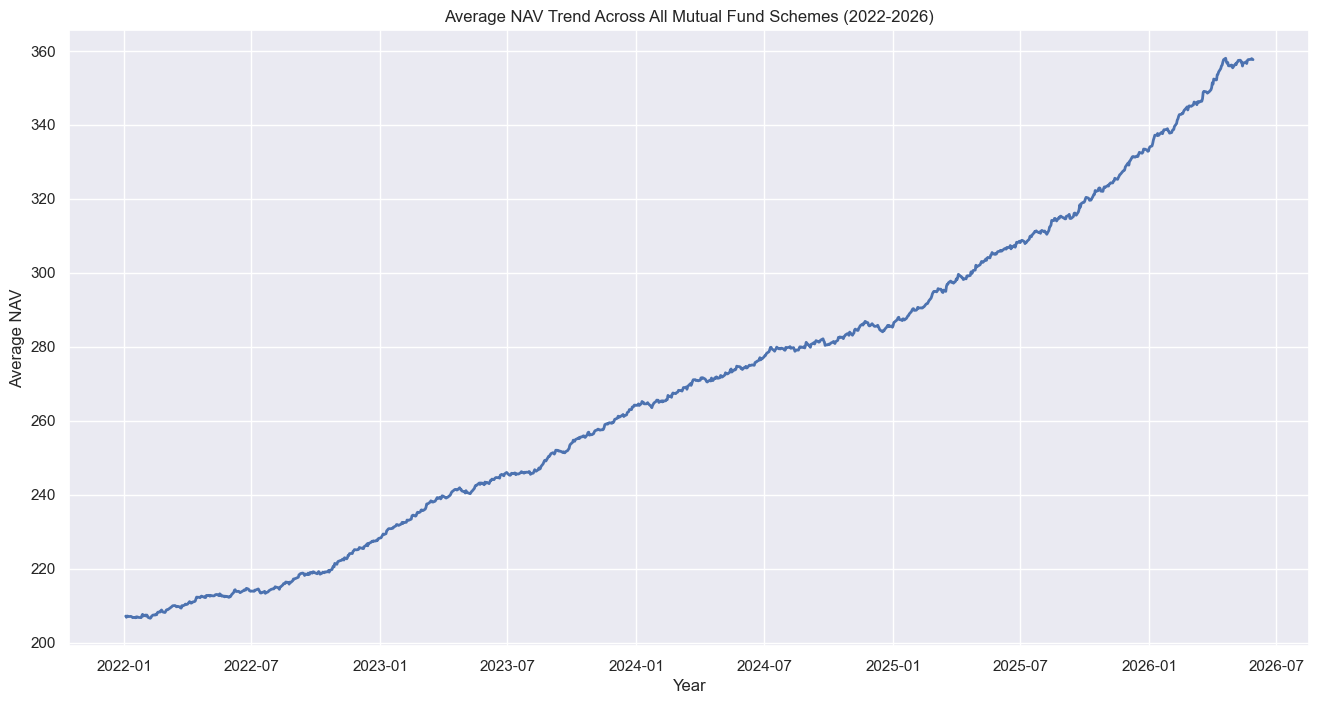

In [6]:
plt.figure(figsize=(16,8))

plt.plot(daily_nav['date'], daily_nav['nav'], linewidth=2)

plt.title('Average NAV Trend Across All Mutual Fund Schemes (2022-2026)')

plt.xlabel('Year')
plt.ylabel('Average NAV')

plt.grid(True)

plt.show()

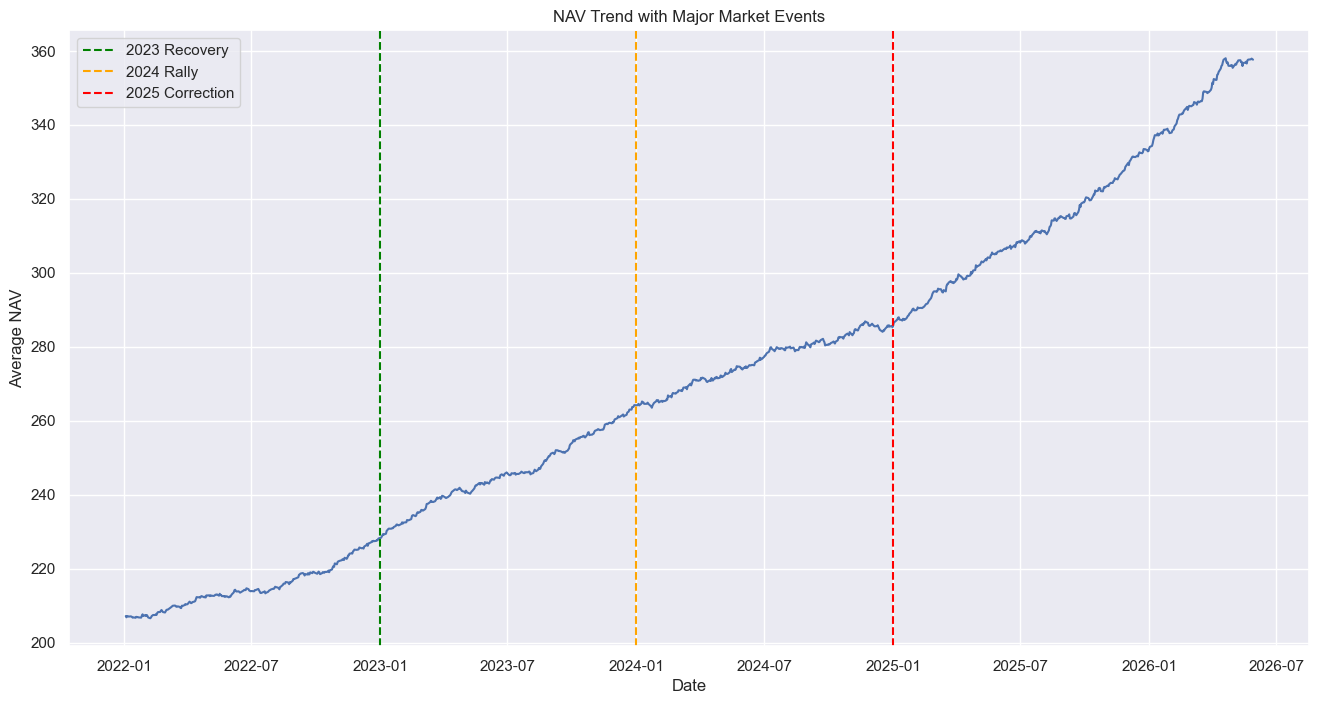

In [7]:
plt.figure(figsize=(16,8))

plt.plot(daily_nav['date'], daily_nav['nav'])

# COVID Recovery
plt.axvline(pd.Timestamp('2023-01-01'),color='green',linestyle='--',label='2023 Recovery')

# Rally
plt.axvline(pd.Timestamp('2024-01-01'),color='orange',linestyle='--',label='2024 Rally')

# Correction
plt.axvline(pd.Timestamp('2025-01-01'),color='red',linestyle='--',label='2025 Correction')

plt.title('NAV Trend with Major Market Events')

plt.xlabel('Date')
plt.ylabel('Average NAV')

plt.legend()

plt.show()

# 2

In [8]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd() / "mutual_fund_project"

aum_path = project_root / "data" / "raw" / "03_aum_by_fund_house.csv"

print(aum_path)

aum_df = pd.read_csv(aum_path)

aum_df.head()

C:\Users\Shruti Singhania\mutual_fund_project\data\raw\03_aum_by_fund_house.csv


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [9]:
aum_df['date'] = pd.to_datetime(aum_df['date'],format='mixed')

In [10]:
aum_df['year'] = aum_df['date'].dt.year

aum_df[['date','year']].head()

,date,year
0,2022-03-31,2022
1,2022-03-31,2022
2,2022-03-31,2022
3,2022-03-31,2022
4,2022-03-31,2022


In [11]:
year_end_aum = aum_df[
    aum_df['date'].dt.month == 3
].copy()

year_end_aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


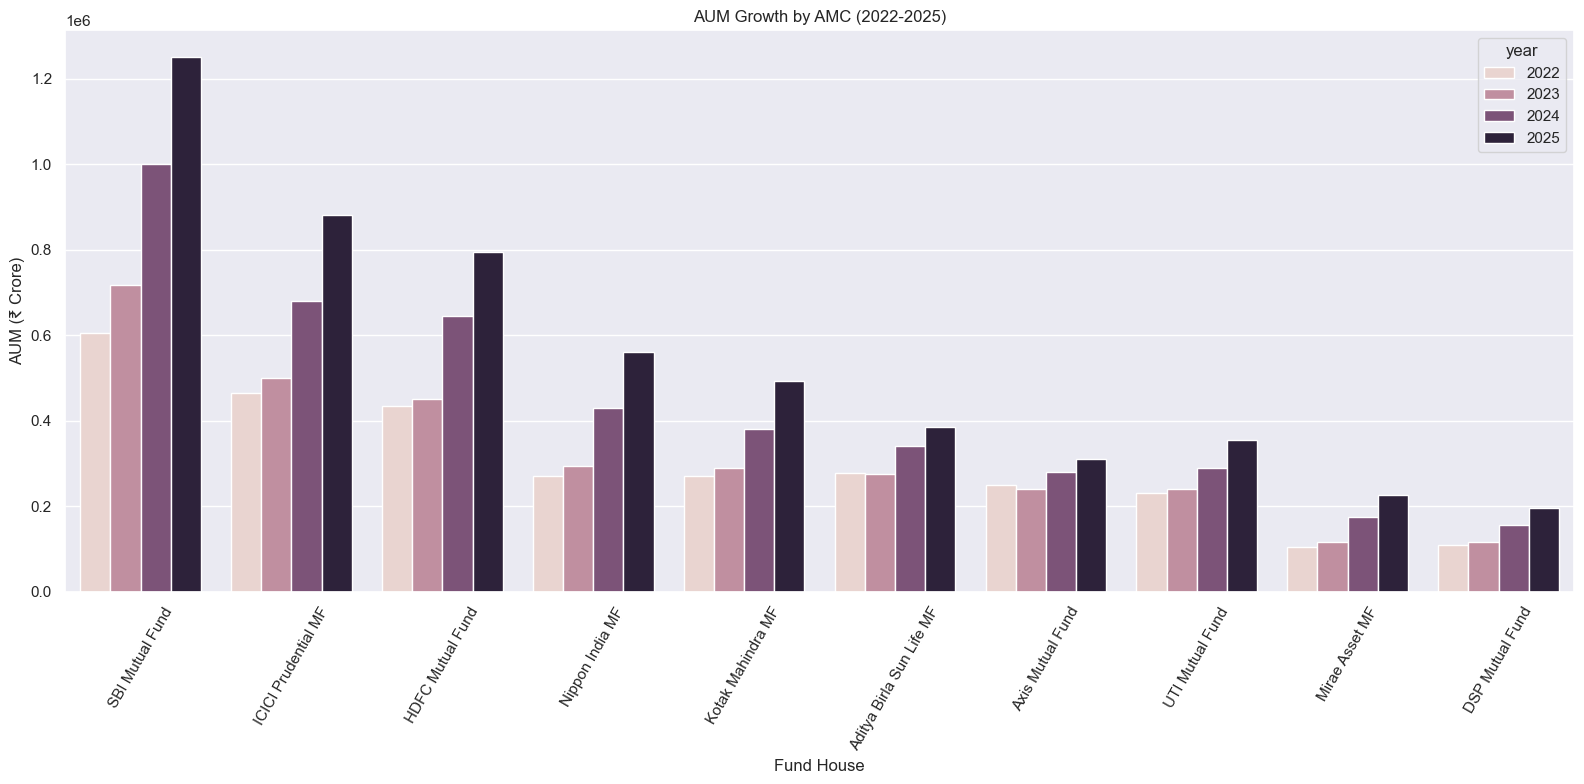

In [12]:
plt.figure(figsize=(16,8))

sns.barplot(data=year_end_aum, x='fund_house',y='aum_crore',hue='year')

plt.title('AUM Growth by AMC (2022-2025)')
plt.xlabel('Fund House')
plt.ylabel('AUM (₹ Crore)')
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

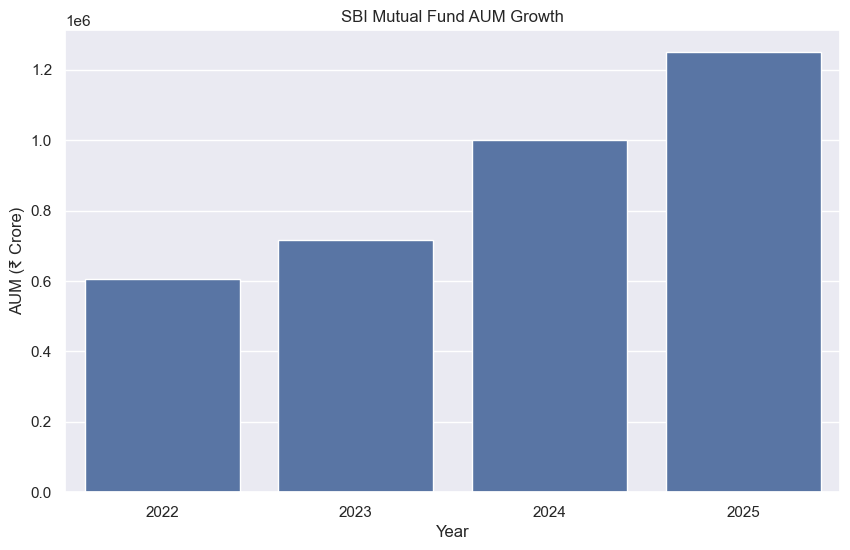

In [13]:
sbi_data = year_end_aum[year_end_aum['fund_house'] == 'SBI Mutual Fund']

plt.figure(figsize=(10,6))

sns.barplot(data=sbi_data, x='year', y='aum_crore')

plt.title('SBI Mutual Fund AUM Growth')
plt.ylabel('AUM (₹ Crore)')
plt.xlabel('Year')

plt.show()

# 3

In [14]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd() / "mutual_fund_project"

sip_path = project_root / "data" / "raw" / "04_monthly_sip_inflows.csv"

print(sip_path)

sip_df = pd.read_csv(sip_path)

sip_df.head()

C:\Users\Shruti Singhania\mutual_fund_project\data\raw\04_monthly_sip_inflows.csv


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [15]:
sip_df['month'] = pd.to_datetime(sip_df['month'],format='mixed')

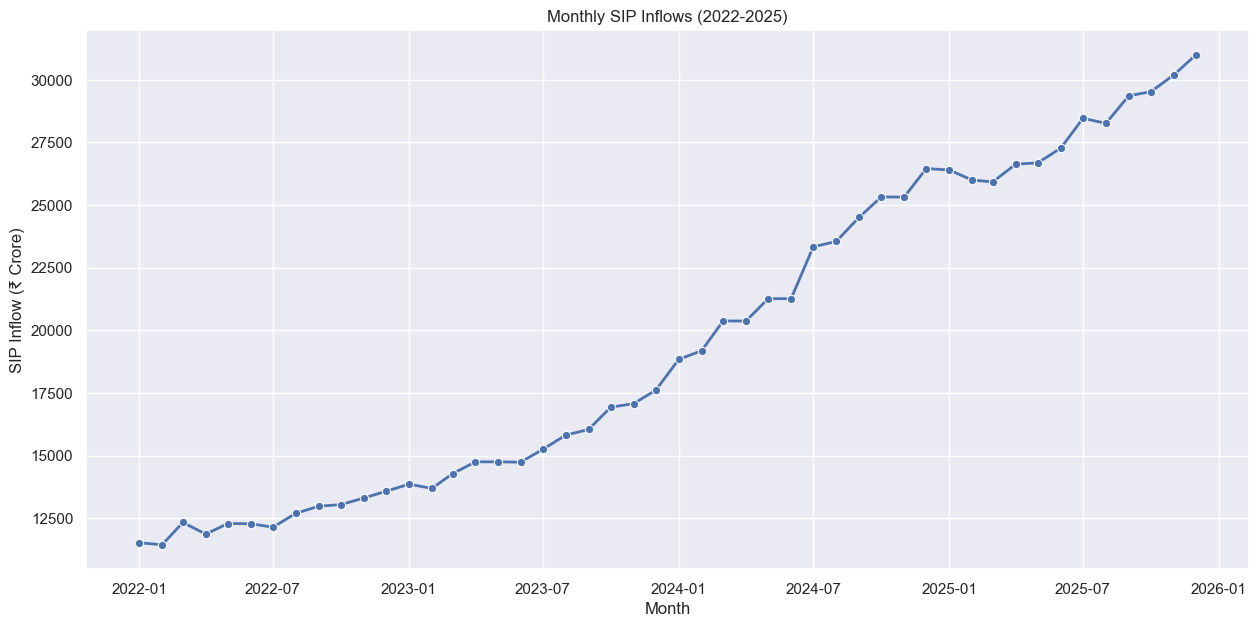

In [16]:
plt.figure(figsize=(15,7))

sns.lineplot(data=sip_df,x='month', y='sip_inflow_crore',marker='o',linewidth=2)

plt.title('Monthly SIP Inflows (2022-2025)')
plt.xlabel('Month')
plt.ylabel('SIP Inflow (₹ Crore)')

plt.grid(True)

plt.show()

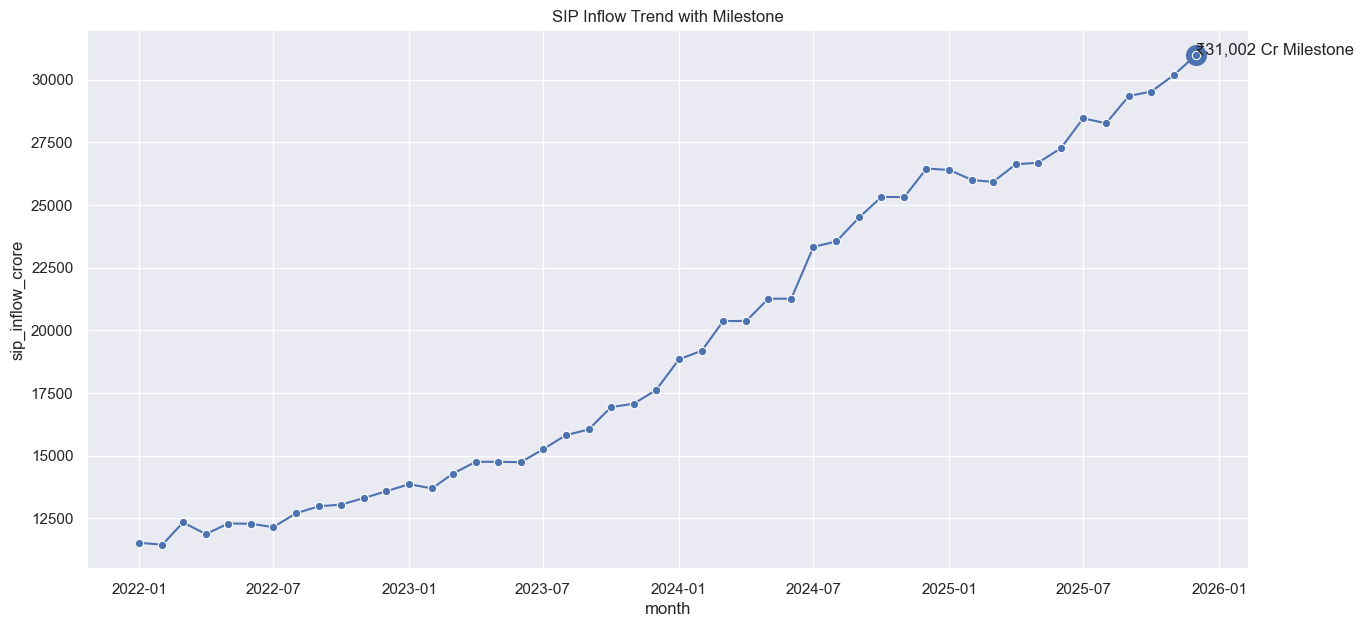

In [17]:
plt.figure(figsize=(15,7))

sns.lineplot(data=sip_df, x='month', y='sip_inflow_crore', marker='o')

milestone = sip_df[sip_df['sip_inflow_crore'] >= 31002]

if len(milestone) > 0:

    first_hit = milestone.iloc[0]

    plt.scatter(
        first_hit['month'],
        first_hit['sip_inflow_crore'],
        s=200
    )

    plt.annotate(
        '₹31,002 Cr Milestone',
        (
            first_hit['month'],
            first_hit['sip_inflow_crore']
        )
    )

plt.title('SIP Inflow Trend with Milestone')
plt.show()

# 4

In [18]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd() / "mutual_fund_project"

cat_path = project_root / "data" / "raw" / "05_category_inflows.csv"

print(cat_path)

cat_df = pd.read_csv(cat_path)

cat_df.head()

C:\Users\Shruti Singhania\mutual_fund_project\data\raw\05_category_inflows.csv


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [19]:
heatmap_data = cat_df.pivot(index='category', columns='month', values='net_inflow_crore')

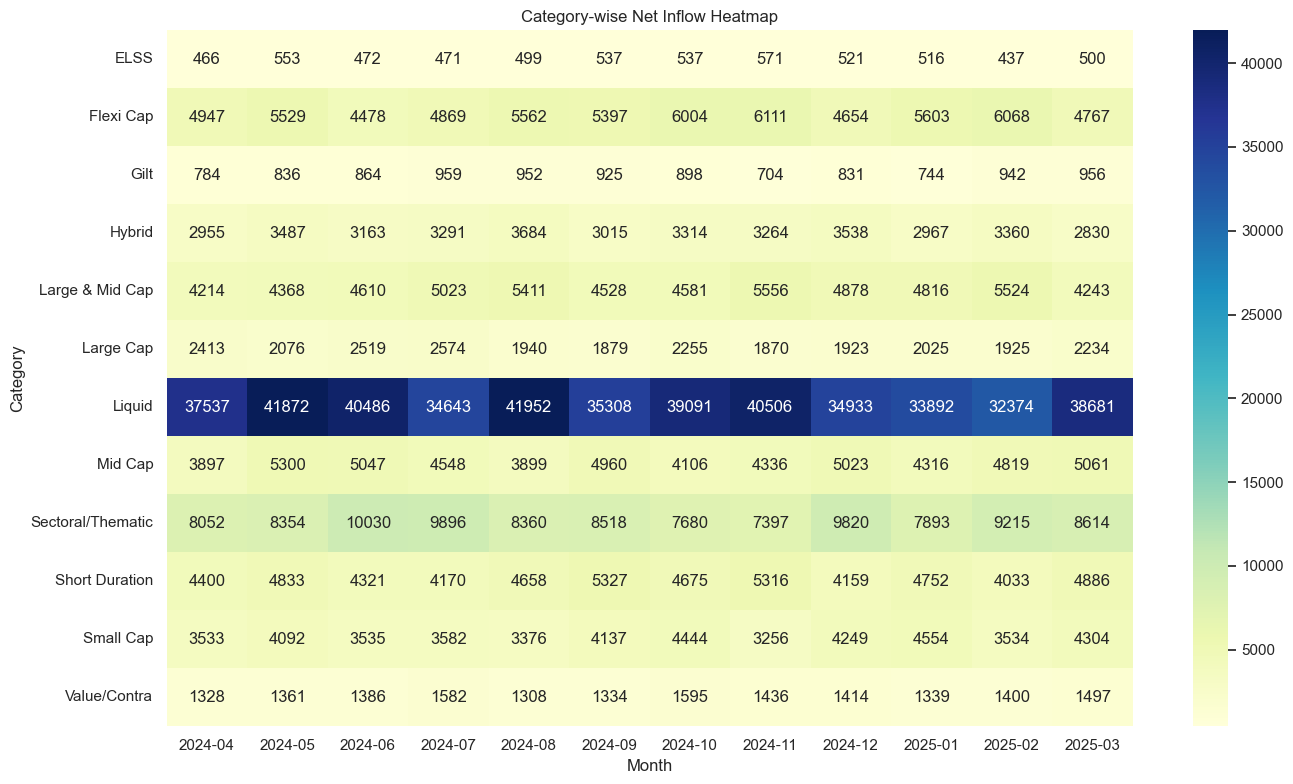

In [20]:
plt.figure(figsize=(14,8))

sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu')

plt.title('Category-wise Net Inflow Heatmap')
plt.xlabel('Month')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

# 5

In [21]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd() / "mutual_fund_project"

inv_path = project_root / "data" / "raw" / "08_investor_transactions.csv"

print(inv_path)

inv_df = pd.read_csv(inv_path)

inv_df.head()

C:\Users\Shruti Singhania\mutual_fund_project\data\raw\08_investor_transactions.csv


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,01-01-2024,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,01-01-2024,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,01-01-2024,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,01-01-2024,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,01-01-2024,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [22]:
age_dist = inv_df['age_group'].value_counts()
age_dist

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

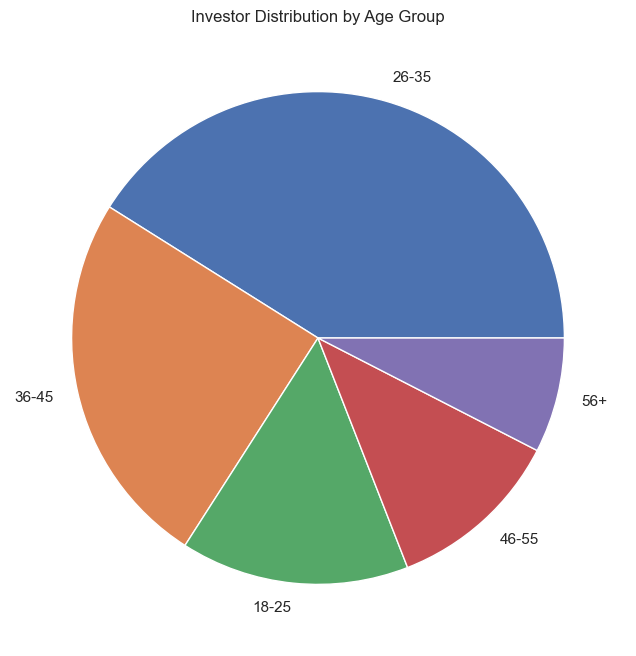

In [23]:
plt.figure(figsize=(8,8))

plt.pie(age_dist,labels=age_dist.index)

plt.title('Investor Distribution by Age Group')

plt.show()

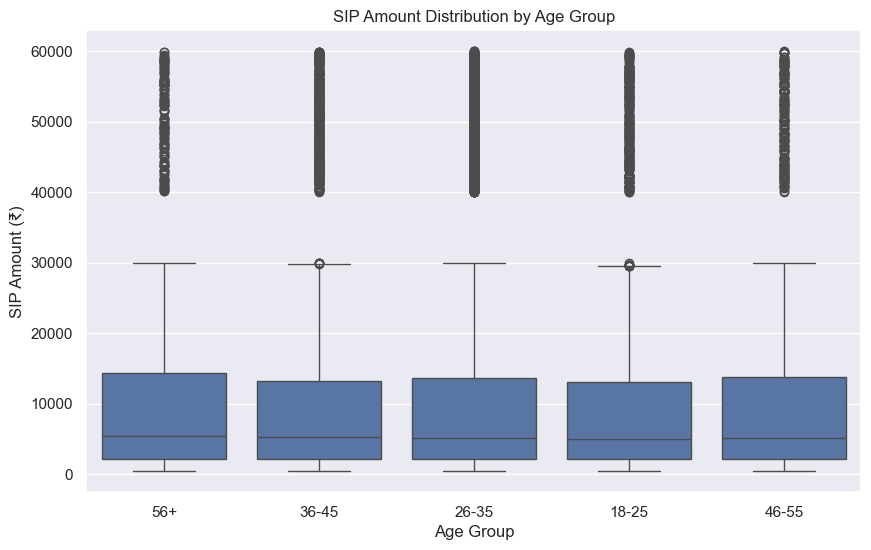

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sip_df = inv_df[inv_df['transaction_type'] == 'SIP']

plt.figure(figsize=(10,6))

sns.boxplot(data=sip_df, x='age_group', y='amount_inr')

plt.title('SIP Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('SIP Amount (₹)')

plt.show()

# 6

In [25]:
state_dist = inv_df['state'].value_counts()
state_dist

state
Punjab            2965
Madhya Pradesh    2931
Tamil Nadu        2806
Gujarat           2780
West Bengal       2748
Haryana           2736
Telangana         2718
Uttar Pradesh     2695
Delhi             2677
Karnataka         2621
Rajasthan         2577
Maharashtra       2524
Name: count, dtype: int64

In [26]:
sip_df = inv_df[inv_df['transaction_type'] == 'SIP']

state_sip = (sip_df.groupby('state')['amount_inr'].sum().sort_values(ascending=False).reset_index())

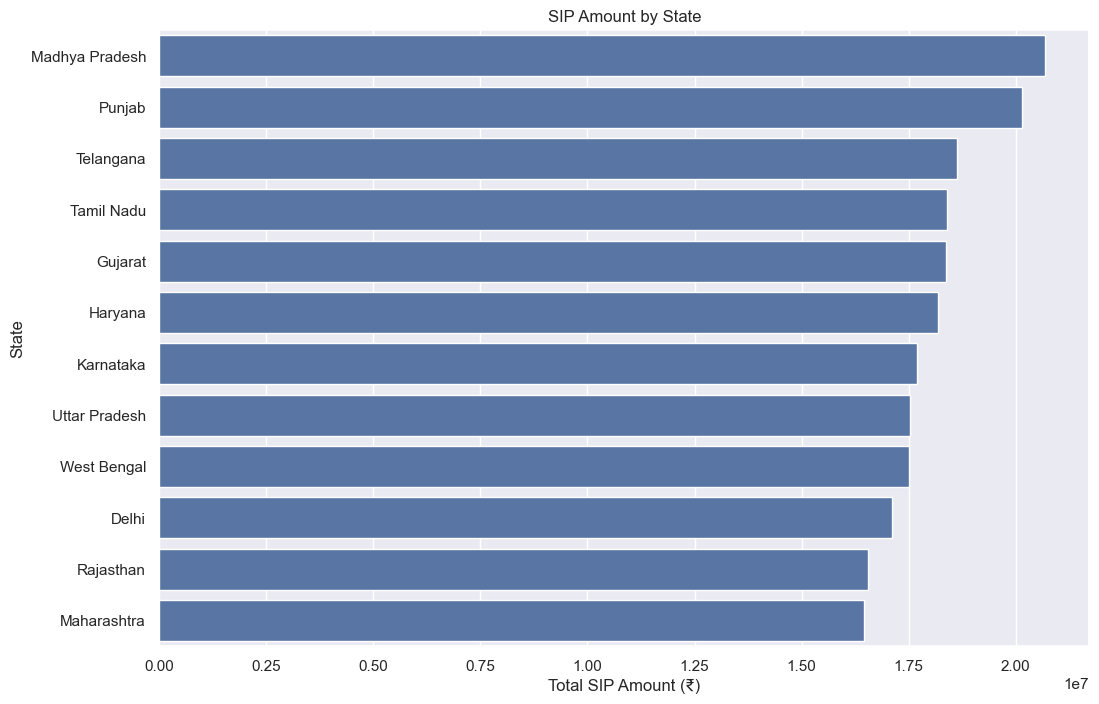

In [27]:
plt.figure(figsize=(12,8))

sns.barplot(data=state_sip, x='amount_inr', y='state')

plt.title('SIP Amount by State')
plt.xlabel('Total SIP Amount (₹)')
plt.ylabel('State')

plt.show()

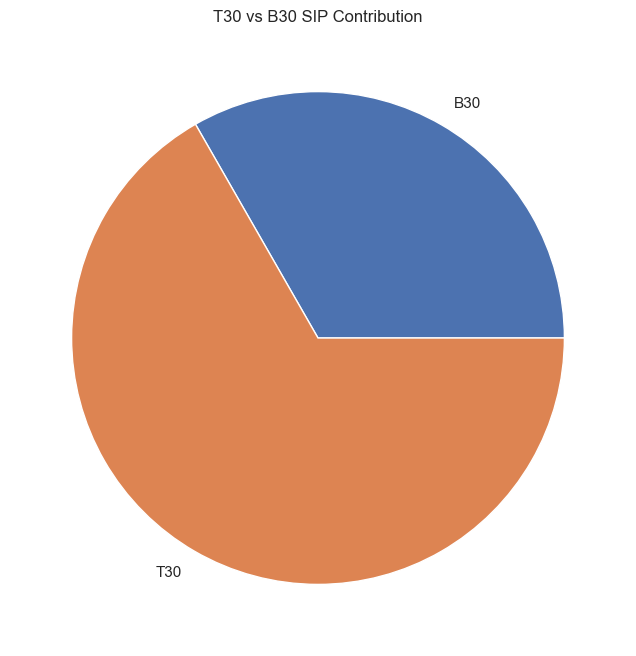

In [28]:
tier_dist = (sip_df.groupby('city_tier')['amount_inr'].sum())

plt.figure(figsize=(8,8))

plt.pie(tier_dist, labels=tier_dist.index)

plt.title('T30 vs B30 SIP Contribution')

plt.show()

# 7

In [29]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd() / "mutual_fund_project"

folio_path = project_root / "data" / "raw" / "06_industry_folio_count.csv"

print(folio_path)

folio_df = pd.read_csv(folio_path)

folio_df.head()

C:\Users\Shruti Singhania\mutual_fund_project\data\raw\06_industry_folio_count.csv


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [30]:
folio_df['month'] = pd.to_datetime(folio_df['month'],format='%Y-%m')

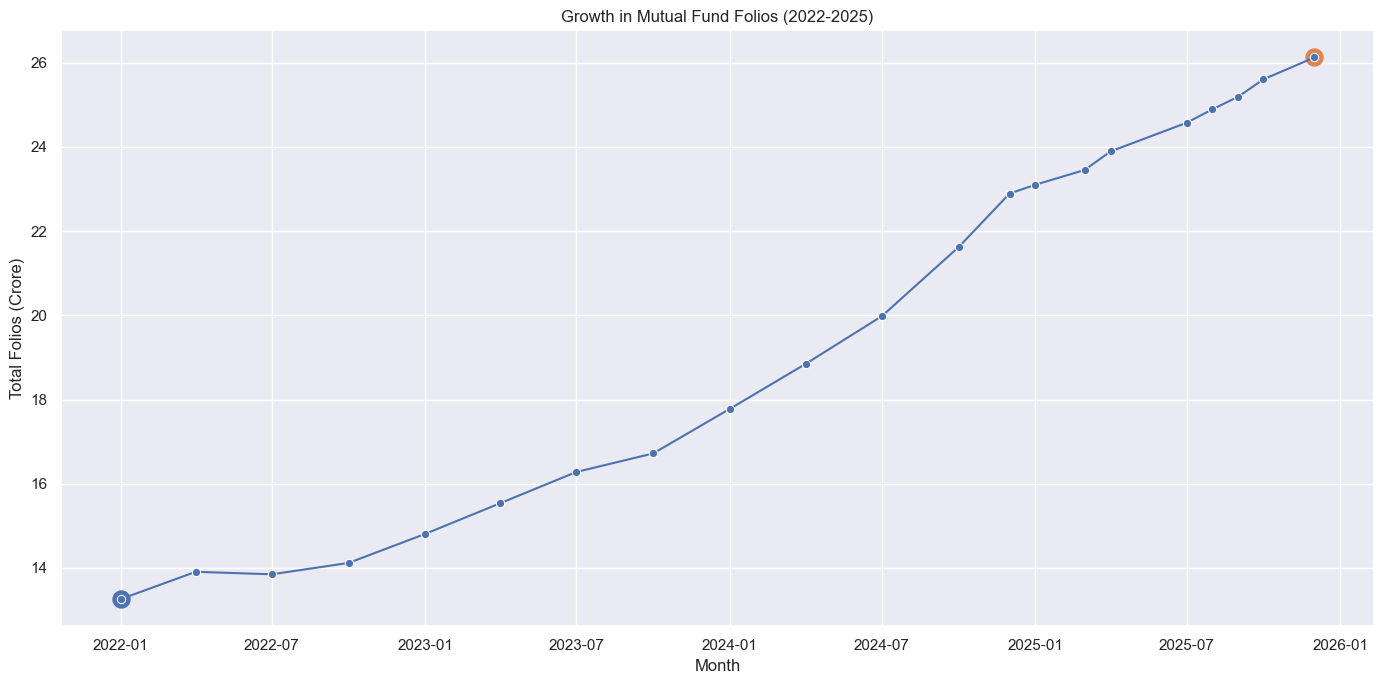

In [31]:
plt.figure(figsize=(14,7))

sns.lineplot(data=folio_df, x='month', y='total_folios_crore', marker='o')

plt.scatter(folio_df.iloc[0]['month'], folio_df.iloc[0]['total_folios_crore'], s=150)

plt.scatter(folio_df.iloc[-1]['month'], folio_df.iloc[-1]['total_folios_crore'], s=150)

plt.title('Growth in Mutual Fund Folios (2022-2025)')
plt.xlabel('Month')
plt.ylabel('Total Folios (Crore)')

plt.grid(True)

plt.tight_layout()
plt.show()

# 8

In [32]:
top_funds = nav_df['amfi_code'].unique()[:10]

In [33]:
nav_subset = nav_df[nav_df['amfi_code'].isin(top_funds)]

In [34]:
nav_pivot = nav_subset.pivot(index='date', columns='amfi_code', values='nav')

In [35]:
returns = nav_pivot.pct_change().dropna()

In [36]:
corr_matrix = returns.corr()

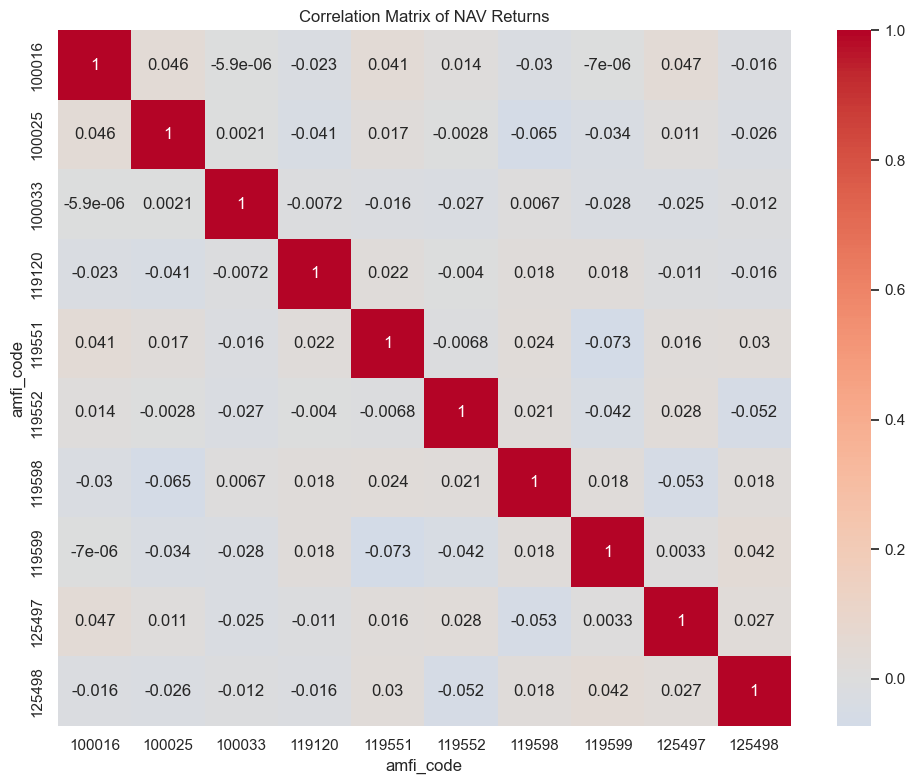

In [37]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of NAV Returns')

plt.tight_layout()
plt.show()

# 9

In [38]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd() / "mutual_fund_project"

hold_path = project_root / "data" / "raw" / "09_portfolio_holdings.csv"

print(hold_path)

holdings_df = pd.read_csv(hold_path)

holdings_df.head()

C:\Users\Shruti Singhania\mutual_fund_project\data\raw\09_portfolio_holdings.csv


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [39]:
sector_weights = (holdings_df.groupby('sector')['weight_pct'].sum().sort_values(ascending=False))
sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

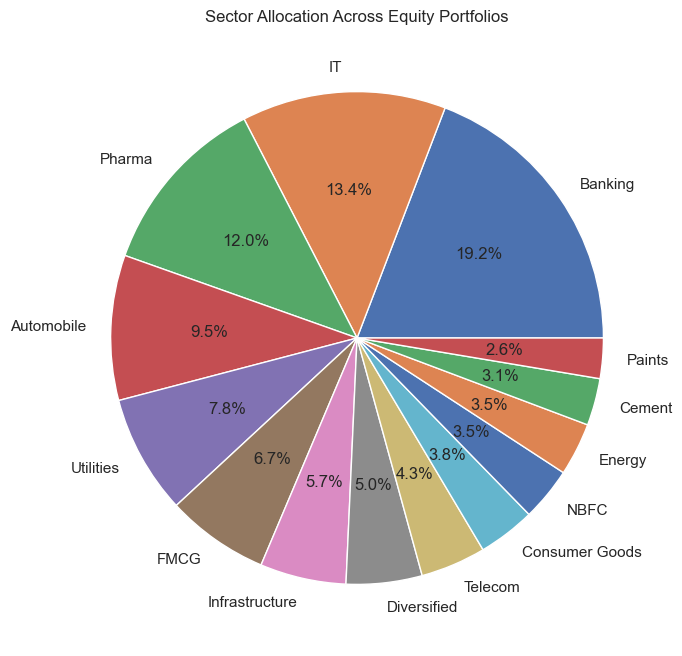

In [40]:
plt.figure(figsize=(10,8))
plt.pie(sector_weights,labels=sector_weights.index,autopct='%1.1f%%')
plt.title('Sector Allocation Across Equity Portfolios')

plt.show()

# 10

# Key EDA Findings

### 1. Consistent Growth in Mutual Fund NAVs

The average NAV across mutual fund schemes showed a generally upward trend from 2022 to 2025, indicating sustained market growth despite short-term fluctuations.

### 2. SBI Mutual Fund Maintained AUM Leadership

Among all fund houses, SBI Mutual Fund consistently recorded the highest Assets Under Management (AUM), maintaining a significant lead over competitors.

### 3. Industry-Wide AUM Expansion

Most AMCs experienced steady AUM growth across the analysis period, reflecting increasing investor participation in mutual funds.

### 4. SIP Inflows Reached Record Levels

Monthly SIP inflows increased substantially between 2022 and 2025, highlighting growing investor preference for systematic investing.

### 5. SIP Account Base Expanded Rapidly

The number of active SIP accounts increased continuously, indicating stronger retail investor engagement and improved financial awareness.

### 6. Sectoral and Thematic Funds Attracted Strong Inflows

Among equity-oriented categories, Sectoral/Thematic funds received some of the highest net inflows, demonstrating investor interest in focused investment themes.

### 7. Investors Concentrated in the 26–45 Age Group

The majority of investors belonged to the working-age population, particularly the 26–35 and 36–45 age groups.

### 8. T30 Cities Contributed a Larger Share of SIP Investments

Top 30 cities accounted for a greater proportion of SIP investments, although B30 cities also showed meaningful participation.

### 9. Mutual Fund Folios Nearly Doubled

Total folio count grew from approximately 13.26 crore in early 2022 to over 26 crore by the end of 2025, indicating strong expansion of the investor base.

### 10. Portfolios Were Concentrated in a Few Key Sectors

Banking, IT, Pharma, Utilities, and Automobile sectors constituted a major share of portfolio allocations, reflecting their importance in equity mutual fund holdings.
